# School Enrolment Trends Data Visualisation Analysis Project

Authored by: Hanwen Dun   
Duration: 90 mins   
Level: Intermediate   
Pre-requisite Skills: Python, pandas, matplotlib, seaborn, basic statistics   

## Objective

The goal of this use case is to analyse school enrolment trends using a real-world education dataset. This involves examining how student numbers change over time, comparing enrolment across different regions or school types, and visualising these trends using data visualisation techniques.

Through this analysis, we aim to identify patterns in school enrolment that can help education planners understand student demand and support better resource allocation in the education system.

## Scenario

In this scenario, you take on the role of a data analyst working for an education department or school administration authority.

Your task is to analyse school enrolment data to answer several important questions related to education planning and student population trends.

Specifically, you aim to understand:

1. How student enrolment has changed over time.

2. Which regions have the highest or lowest enrolment numbers.

3. Whether enrolment patterns differ between different school types.

4. How enrolment trends may develop in the future.

By analysing these patterns, decision makers can better plan school infrastructure, allocate teachers, and manage education resources effectively.

## What this use case will teach you

### At the end of this use case you will:

This use case provides hands-on experience in processing, cleaning, and analysing education data. You will gain insights in:

1. Data Cleaning and Preparation  
Learn how to clean and preprocess education datasets using pandas, including handling missing values and formatting data correctly.

2. Trend Analysis  
Analyse how school enrolment changes across different years and identify long-term trends in student numbers.

3. Regional Comparison  
Compare enrolment patterns across different geographic regions or school categories.

4. Data Visualisation  
Use visualisation tools such as matplotlib and seaborn to create charts that clearly communicate data insights.

5. Basic Predictive Insights  
Explore simple techniques to estimate future enrolment trends based on historical data.

## Importing Required Libraries

In [111]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from io import StringIO

## Importing the required dataset

In [113]:
# API base address
base_url = "https://discover.data.vic.gov.au/api/3/action/datastore_search"

resource_id = "a70cb615-ed28-48b6-bebe-2d0d346f7927"

url = f"{base_url}?resource_id={resource_id}&limit=5000"

response = requests.get(url)

if response.status_code == 200:
    
    data = response.json()
    
    school_locations_df = pd.DataFrame(data["result"]["records"])
    
    print(school_locations_df.head())

else:
    
    print(f"Request failed with status code {response.status_code}")

   _id Education_Sector Entity_Type School_No                    School_Name  \
0    1         Catholic           2        20                 Parade College   
1    2         Catholic           2        25       Simonds Catholic College   
2    3         Catholic           2        26    St Mary’s College Melbourne   
3    4         Catholic           2        28  St Patrick's College Ballarat   
4    5         Catholic           2        29            St Patrick's School   

  School_Type             Address_Line_1 Address_Line_2    Address_Town  \
0   Secondary           1436 Plenty Road           None        BUNDOORA   
1   Secondary        273 Victoria Street           None  WEST MELBOURNE   
2   Secondary         11 Westbury Street           None   ST KILDA EAST   
3   Secondary          1431 Sturt Street           None        BALLARAT   
4     Primary  119 Drummond Street South           None        BALLARAT   

  Address_State  ...     Postal_Town Postal_State Postal_Postcode  \

This dataset provides detailed information on school locations across Victoria. It includes key attributes such as school name, education sector, school type, and administrative regions, along with address details and geographic coordinates (latitude and longitude). The dataset enables spatial and regional analysis of schools, supporting further integration with enrolment data for comprehensive analysis.

In [114]:
# API base address
base_url = "https://www.education.vic.gov.au/Documents/about/research/datavic"

dataset_id = "dv377_DataVic-AllSchoolsEnrolments-2024.csv"

url = f"{base_url}/{dataset_id}"

params = {}

response = requests.get(url, params=params)

if response.status_code == 200:
    
    url_content = response.content.decode("latin1")
    
    enrolments_df = pd.read_csv(StringIO(url_content))
    
    print(enrolments_df.head())

else:
    
    print(f"Request failed with status code {response.status_code}")

  Education_Sector  Entity_Type  School_No                    School_Name  \
0         Catholic            2         20                 Parade College   
1         Catholic            2         25       Simonds Catholic College   
2         Catholic            2         26    St Marys College Melbourne   
3         Catholic            2         28  St Patrick's College Ballarat   
4         Catholic            2         29            St Patrick's School   

  School_Type School_Status         DE_Admin_Region          LGA_Name  \
0   Secondary             O  NORTH-WESTERN VICTORIA       Banyule (C)   
1   Secondary             O  SOUTH-WESTERN VICTORIA     Melbourne (C)   
2   Secondary             O  SOUTH-EASTERN VICTORIA  Port Phillip (C)   
3   Secondary             O  SOUTH-WESTERN VICTORIA      Ballarat (C)   
4     Primary             O  SOUTH-WESTERN VICTORIA      Ballarat (C)   

             DE_Admin_AREA  Prep Total""  ...  Year 8 Total""  Year 9 Total""  \
0  North Eastern 

This dataset contains student enrolment information for schools in Victoria, including total enrolments and breakdowns by year level. It also includes school characteristics such as sector, type, and regional classification. The dataset enables analysis of enrolment patterns across different school levels, sectors, and geographic regions.

In [115]:
school_locations_df.info()
enrolments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2294 entries, 0 to 2293
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   _id                    2294 non-null   int64 
 1   Education_Sector       2294 non-null   object
 2   Entity_Type            2294 non-null   object
 3   School_No              2294 non-null   object
 4   School_Name            2294 non-null   object
 5   School_Type            2294 non-null   object
 6   Address_Line_1         2294 non-null   object
 7   Address_Line_2         11 non-null     object
 8   Address_Town           2294 non-null   object
 9   Address_State          2294 non-null   object
 10  Address_Postcode       2294 non-null   object
 11  Postal_Address_Line_1  2292 non-null   object
 12  Postal_Address_Line_2  14 non-null     object
 13  Postal_Town            2292 non-null   object
 14  Postal_State           2292 non-null   object
 15  Postal_Postcode      

The dataset structure shows that both datasets are well-organised, with a clear range of variables describing school characteristics, locations, and enrolment data. Most columns have complete entries, indicating good data quality. The enrolment dataset mainly consists of numerical variables representing student counts across different year levels, while the location dataset contains categorical and textual information such as school details and geographic attributes. Overall, the datasets are suitable for integration and further analysis.

## Dataset preprocessing

In [117]:
print("\nMissing values in School Locations Dataset:")
print(school_locations_df.isnull().sum())


Missing values in School Locations Dataset:
_id                         0
Education_Sector            0
Entity_Type                 0
School_No                   0
School_Name                 0
School_Type                 0
Address_Line_1              0
Address_Line_2           2283
Address_Town                0
Address_State               0
Address_Postcode            0
Postal_Address_Line_1       2
Postal_Address_Line_2    2280
Postal_Town                 2
Postal_State                2
Postal_Postcode             2
Full_Phone_No               0
DE_Admin_Region             0
DE_Admin_AREA               0
LGA_ID                      0
LGA_Name                    0
X                           1
Y                           1
dtype: int64


The missing values analysis shows that most key variables in the school locations dataset are complete, particularly those related to school identification, sector, and geographic information. However, some address-related fields, such as Address_Line_2 and postal address columns, contain a higher number of missing values. A small number of missing values are also observed in the coordinate fields (X and Y), which were addressed during data cleaning to ensure reliability for spatial analysis.

In [118]:
print("\nMissing values in Enrolments Dataset:")
print(enrolments_df.isnull().sum())


Missing values in Enrolments Dataset:
Education_Sector              0
Entity_Type                   0
School_No                     0
School_Name                   0
School_Type                   0
School_Status                 0
DE_Admin_Region               0
LGA_Name                      0
DE_Admin_AREA                 0
Prep Total""                  0
Year 1 Total""                0
Year 2 Total""                0
Year 3 Total""                0
Year 4 Total""                0
Year 5 Total""                0
Year 6 Total""                0
Primary Ungraded Total""      0
Primary Total""               0
Year 7 Total""                0
Year 8 Total""                0
Year 9 Total""                0
Year 10 Total""               0
Year 11 Total""               0
Year 12 Total""               0
Secondary Ungraded Total""    0
Secondary Total""             0
Grand Total""                 0
Year                          0
CENSUS_TYPE                   0
dtype: int64


The enrolments dataset shows no missing values across all variables, indicating a high level of data completeness and reliability. This ensures that the dataset is suitable for accurate analysis of student numbers across different year levels, sectors, and regions.

In [119]:
# Remove columns with many missing values that are not required for analysis
location_cols_to_drop = [
    'Address_Line_2',
    'Postal_Address_Line_1',
    'Postal_Address_Line_2',
    'Postal_Town',
    'Postal_State',
    'Postal_Postcode'
]

school_locations_df = school_locations_df.drop(
    columns=[col for col in location_cols_to_drop if col in school_locations_df.columns],
    errors='ignore'
)

# Remove rows with missing coordinates
coord_cols = [col for col in ['X', 'Y'] if col in school_locations_df.columns]
if coord_cols:
    school_locations_df = school_locations_df.dropna(subset=coord_cols)

print("Missing values in cleaned School Locations Dataset:")
print(school_locations_df.isnull().sum())

Missing values in cleaned School Locations Dataset:
_id                 0
Education_Sector    0
Entity_Type         0
School_No           0
School_Name         0
School_Type         0
Address_Line_1      0
Address_Town        0
Address_State       0
Address_Postcode    0
Full_Phone_No       0
DE_Admin_Region     0
DE_Admin_AREA       0
LGA_ID              0
LGA_Name            0
X                   0
Y                   0
dtype: int64


The cleaned school locations dataset shows no remaining missing values across all key variables. This indicates that the data preprocessing steps were successful in ensuring completeness and reliability. As a result, the dataset is well-prepared for subsequent analysis and visualisation.

In [120]:
print("School Locations columns:")
print(school_locations_df.columns)

print("\nEnrolments columns:")
print(enrolments_df.columns)

School Locations columns:
Index(['_id', 'Education_Sector', 'Entity_Type', 'School_No', 'School_Name',
       'School_Type', 'Address_Line_1', 'Address_Town', 'Address_State',
       'Address_Postcode', 'Full_Phone_No', 'DE_Admin_Region', 'DE_Admin_AREA',
       'LGA_ID', 'LGA_Name', 'X', 'Y'],
      dtype='object')

Enrolments columns:
Index(['Education_Sector', 'Entity_Type', 'School_No', 'School_Name',
       'School_Type', 'School_Status', 'DE_Admin_Region', 'LGA_Name',
       'DE_Admin_AREA', 'Prep Total""', 'Year 1 Total""', 'Year 2 Total""',
       'Year 3 Total""', 'Year 4 Total""', 'Year 5 Total""', 'Year 6 Total""',
       'Primary Ungraded Total""', 'Primary Total""', 'Year 7 Total""',
       'Year 8 Total""', 'Year 9 Total""', 'Year 10 Total""',
       'Year 11 Total""', 'Year 12 Total""', 'Secondary Ungraded Total""',
       'Secondary Total""', 'Grand Total""', 'Year', 'CENSUS_TYPE'],
      dtype='object')


The column comparison shows that both datasets share common variables such as School_No, School_Name, Education_Sector, and LGA_Name, which enables them to be merged effectively. The school locations dataset primarily contains geographic and administrative information, while the enrolments dataset provides detailed student counts across different year levels. This complementary structure supports comprehensive analysis after data integration.

In [121]:
# Convert School_No to string in both datasets
school_locations_df['School_No'] = school_locations_df['School_No'].astype(str)
enrolments_df['School_No'] = enrolments_df['School_No'].astype(str)

merged_df = pd.merge(
    school_locations_df,
    enrolments_df,
    on='School_No',
    how='inner',
    suffixes=('_location', '_enrolment')
)

merged_df = merged_df.rename(columns={
    'School_Name_location': 'School_Name',
    'Education_Sector_location': 'Education_Sector',
    'LGA_Name_location': 'LGA_Name'
})

print("Merged dataset preview:")
print(merged_df.head())

Merged dataset preview:
   _id Education_Sector Entity_Type_location School_No  \
0    1         Catholic                    2        20   
1    2         Catholic                    2        25   
2    3         Catholic                    2        26   
3    3         Catholic                    2        26   
4    4         Catholic                    2        28   

                     School_Name School_Type_location       Address_Line_1  \
0                 Parade College            Secondary     1436 Plenty Road   
1       Simonds Catholic College            Secondary  273 Victoria Street   
2    St Mary’s College Melbourne            Secondary   11 Westbury Street   
3    St Mary’s College Melbourne            Secondary   11 Westbury Street   
4  St Patrick's College Ballarat            Secondary    1431 Sturt Street   

     Address_Town Address_State Address_Postcode  ... Year 8 Total""  \
0        BUNDOORA           VIC             3083  ...          329.0   
1  WEST MELBOU

The merged dataset combines school location information with enrolment data using a common key. It includes both geographic attributes and detailed student enrolment figures across different year levels. This integrated dataset enables comprehensive analysis of enrolment patterns in relation to school characteristics and regional distribution.

In [122]:
print("Missing values in merged dataset:")
print(merged_df.isnull().sum())
print("Merged dataset shape:")
print(merged_df.shape)

Missing values in merged dataset:
_id                           0
Education_Sector              0
Entity_Type_location          0
School_No                     0
School_Name                   0
School_Type_location          0
Address_Line_1                0
Address_Town                  0
Address_State                 0
Address_Postcode              0
Full_Phone_No                 0
DE_Admin_Region_location      0
DE_Admin_AREA_location        0
LGA_ID                        0
LGA_Name                      0
X                             0
Y                             0
Education_Sector_enrolment    0
Entity_Type_enrolment         0
School_Name_enrolment         0
School_Type_enrolment         0
School_Status                 0
DE_Admin_Region_enrolment     0
LGA_Name_enrolment            0
DE_Admin_AREA_enrolment       0
Prep Total""                  0
Year 1 Total""                0
Year 2 Total""                0
Year 3 Total""                0
Year 4 Total""                0
Year 5

The merged dataset shows no missing values across all variables, indicating that the data integration and preprocessing steps were successful. Both location and enrolment information are complete and consistent, ensuring the dataset is reliable for further analysis and visualisation.

## Data Visualisation and Analysis

### Enrolment Distribution

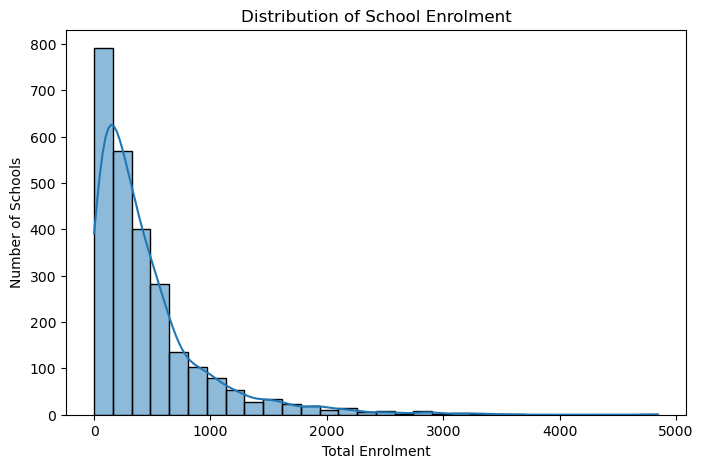

In [125]:
plt.figure(figsize=(8, 5))
sns.histplot(merged_df['Grand Total""'], bins=30, kde=True)

plt.title('Distribution of School Enrolment')
plt.xlabel('Total Enrolment')
plt.ylabel('Number of Schools')

plt.show()

The histogram shows that school enrolment is unevenly distributed, with most schools having relatively small to moderate student populations. The distribution is right-skewed, indicating that a small number of schools have significantly higher enrolment compared to the majority. This suggests variation in school size across Victoria, with only a few large schools accommodating a substantial number of students.

### Top 10 Schools by Enrolment

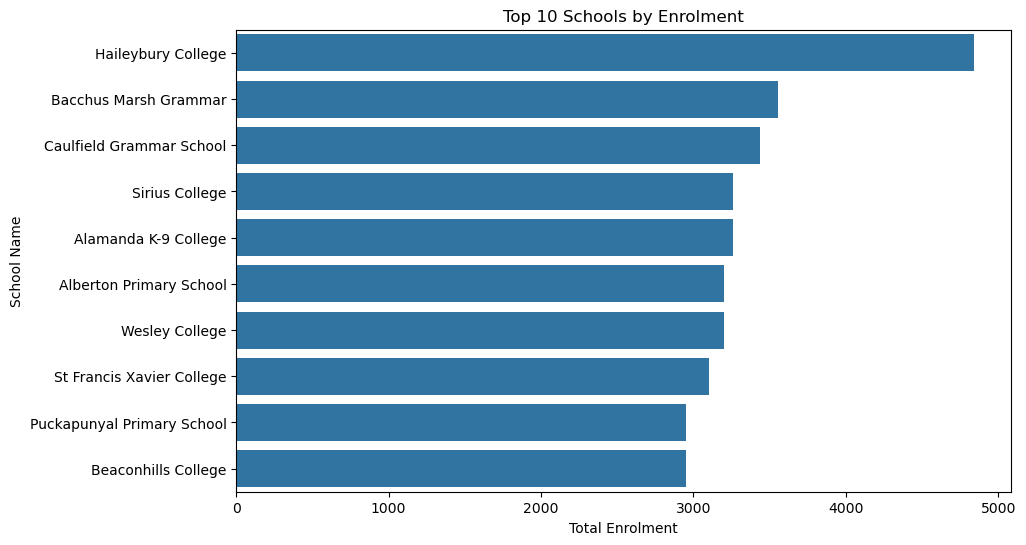

In [127]:
top10 = merged_df.sort_values(by='Grand Total""', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top10,
    x='Grand Total""',
    y='School_Name',
    orient='h'
)

plt.title('Top 10 Schools by Enrolment')
plt.xlabel('Total Enrolment')
plt.ylabel('School Name')

plt.show()

The bar chart highlights the top 10 schools with the highest enrolment. It shows that a small number of schools have significantly larger student populations compared to others, indicating a concentration of students in a few large institutions. The variation in enrolment among these schools also suggests differences in school capacity and demand.

### Enrolment by School Sector

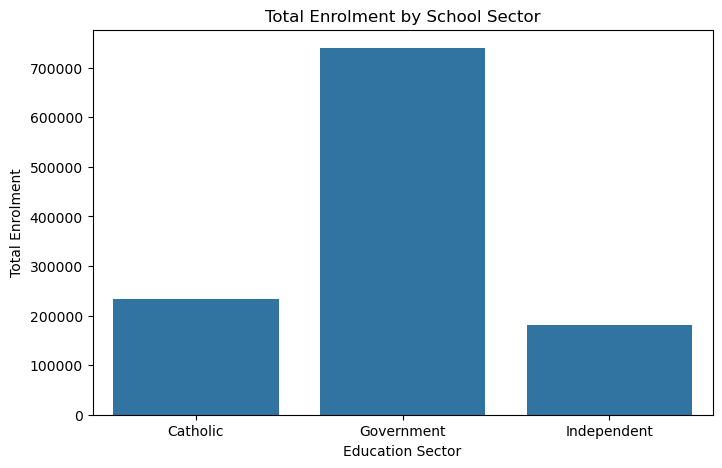

In [130]:
sector_data = (
    merged_df.groupby('Education_Sector')['Grand Total""']
    .sum()
    .reset_index()
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=sector_data,
    x='Education_Sector',
    y='Grand Total""'
)

plt.title('Total Enrolment by School Sector')
plt.xlabel('Education Sector')
plt.ylabel('Total Enrolment')

plt.show()

The bar chart shows that the government sector has the highest total enrolment, significantly exceeding both Catholic and independent schools. This indicates that public schools accommodate the majority of students in Victoria. In contrast, independent schools have the lowest total enrolment, highlighting differences in school accessibility and scale across sectors.

### Enrolment by Region (Top 10 LGA)

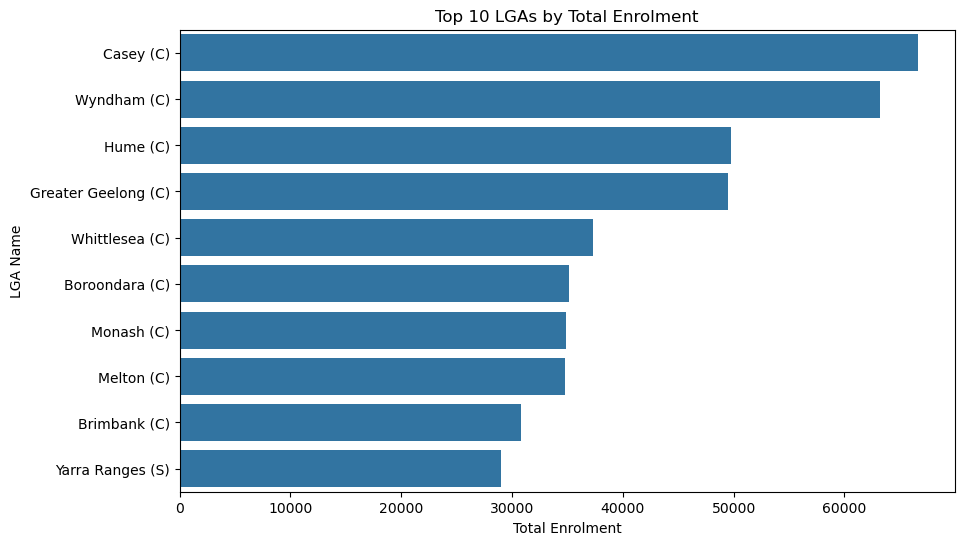

In [134]:
region_data = (
    merged_df.groupby('LGA_Name')['Grand Total""']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=region_data,
    x='Grand Total""',
    y='LGA_Name'
)

plt.title('Top 10 LGAs by Total Enrolment')
plt.xlabel('Total Enrolment')
plt.ylabel('LGA Name')

plt.show()

The chart presents the top 10 LGAs by total enrolment, highlighting that areas such as Casey and Wyndham have the highest student populations. This suggests that these regions experience higher demand for educational resources, likely due to larger or growing populations. In contrast, lower-ranked LGAs have comparatively smaller enrolment, indicating regional variation in population distribution and school demand.

### Heatmap of School Enrolment by Region and Sector

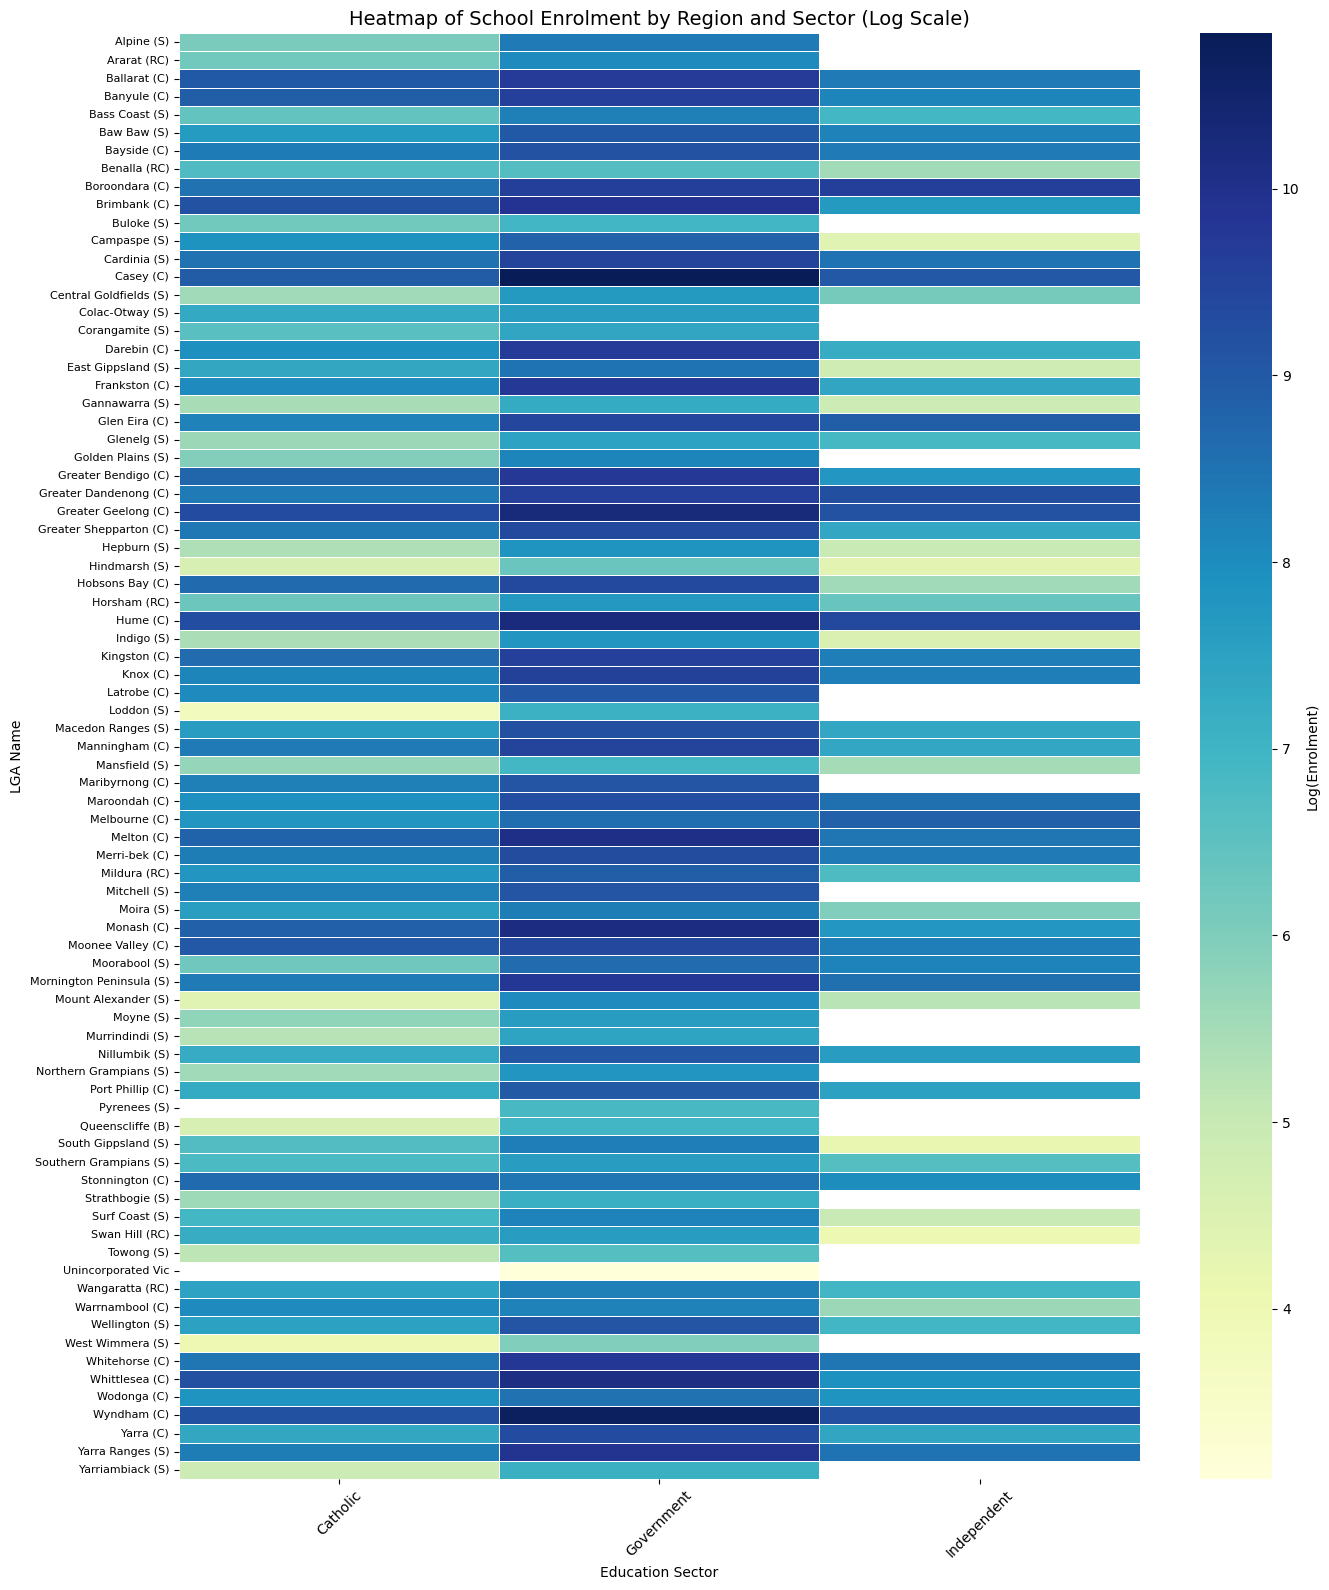

In [136]:
# Create pivot table
heatmap_data = merged_df.pivot_table(
    values='Grand Total""',
    index='LGA_Name',
    columns='Education_Sector',
    aggfunc='sum'
)

# Apply log transformation (important!)
heatmap_data_log = np.log1p(heatmap_data)

# Plot heatmap
plt.figure(figsize=(14, 16))  # bigger size for readability

sns.heatmap(
    heatmap_data_log,
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Log(Enrolment)'}
)

plt.title('Heatmap of School Enrolment by Region and Sector (Log Scale)', fontsize=14)
plt.xlabel('Education Sector')
plt.ylabel('LGA Name')

plt.xticks(rotation=45)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

The heatmap illustrates the distribution of school enrolment across LGAs and education sectors on a logarithmic scale. It shows that government schools consistently have higher enrolment across most regions, while Catholic and independent schools display more variation. The use of a log scale improves visibility of differences across both high and low enrolment areas, highlighting regional disparities in school demand.

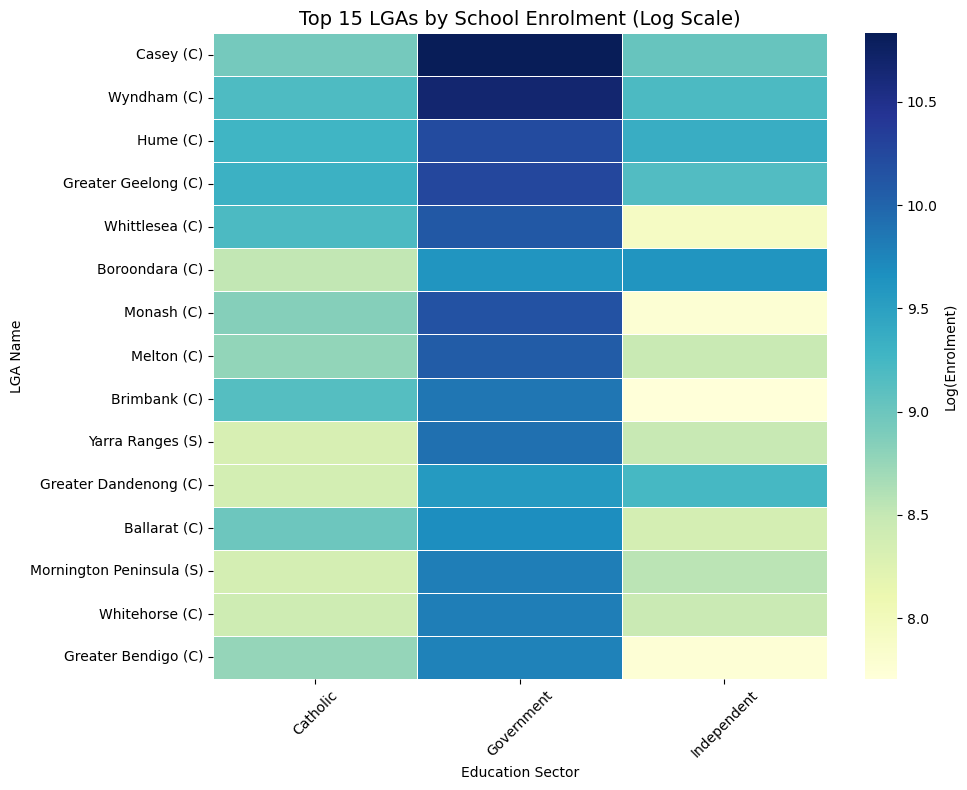

In [138]:
# Create pivot table
heatmap_data = merged_df.pivot_table(
    values='Grand Total""',
    index='LGA_Name',
    columns='Education_Sector',
    aggfunc='sum'
)

# Step 2: Select Top 15 LGAs by total enrolment
top15_lga = heatmap_data.sum(axis=1).sort_values(ascending=False).head(15).index
heatmap_top15 = heatmap_data.loc[top15_lga]

# Step 3: Apply log transformation
heatmap_top15_log = np.log1p(heatmap_top15)

# Plot heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    heatmap_top15_log,
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Log(Enrolment)'}
)

plt.title('Top 15 LGAs by School Enrolment (Log Scale)', fontsize=14)
plt.xlabel('Education Sector')
plt.ylabel('LGA Name')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

The heatmap highlights the top 15 LGAs with the highest school enrolment, showing clear differences across education sectors. Government schools consistently have the highest enrolment in these regions, while Catholic and independent sectors vary more significantly. The logarithmic scale improves comparability, revealing that high-demand LGAs such as Casey and Wyndham dominate overall enrolment.